In [1]:
import argparse
import ast
import multiprocessing
import os
import pathlib
import shutil
import sys

import pandas as pd
import tifffile
from image_analysis_3D.file_utils.notebook_init_utils import (
    avoid_path_crash_bandicoot,
    init_notebook,
)

root_dir, in_notebook = init_notebook()

if in_notebook:
    import tqdm.notebook as tqdm
else:
    import tqdm

In [2]:
def get_z_dimension_size(path: str):
    """
    Get the size of the Z dimension in a TIFF file.
    Parameters
    ----------
    path : str
        Path to the TIFF file.
    Returns
    -------
    int or None
        The size of the Z dimension, or None if it cannot be determined.
    """
    try:
        z_dimension = ast.literal_eval(
            tifffile.TiffFile(path).pages[0].tags.get("ImageDescription").value
        )["shape"][0]
        return z_dimension
    except Exception:
        return None

## Set paths and variables

In [3]:
bandicoot_path = pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve()
image_base_dir = pathlib.Path(f"{bandicoot_path}/NF1_organoid_data").resolve(
    strict=True
)
patients_file_path = pathlib.Path(f"{root_dir}/data/patient_IDs.txt").resolve(
    strict=True
)
patients = pd.read_csv(patients_file_path, header=None)[0].tolist()
# remove the NF0037CQ1 patient from the list
patients.remove("NF0037_T1_CQ1")

table_df_save_path = pathlib.Path(f"../results/table2/file_info_df.parquet").resolve()
table_df_save_path.parent.mkdir(parents=True, exist_ok=True)

In [4]:
# Image extensions that we are looking to copy
image_extensions = {".tif", ".tiff"}
file_paths = {
    "patient": [],
    "well_fov": [],
    "file_path": [],
}

In [5]:
if table_df_save_path.exists():
    print(f"Loading existing file info dataframe from {table_df_save_path}")
    file_paths_df = pd.read_parquet(table_df_save_path)
else:
    # Set channel names
    channel_names = {"405", "488", "555", "640", "TRANS"}
    for patient_id in tqdm.tqdm(
        patients, desc="Processing patients", unit="patient", leave=True
    ):
        well_fov_dirs = [
            dir
            for dir in pathlib.Path(
                f"{image_base_dir}/data/{patient_id}/zstack_images"
            ).glob("*")
            if dir.is_dir()
        ]
        for well_fov_dir in well_fov_dirs:
            well_fov_name = well_fov_dir.name
            for image_file in [
                file
                for file in well_fov_dir.glob("*")
                if file.is_file() and file.suffix in image_extensions
            ]:
                # Check if the file name contains one of the channel names
                if any(
                    channel_name in image_file.name for channel_name in channel_names
                ):
                    file_paths["patient"].append(patient_id)
                    file_paths["well_fov"].append(well_fov_name)
                    file_paths["file_path"].append(str(image_file))
                else:
                    print(
                        f"Warning: File {image_file} does not contain a valid channel name and will be skipped."
                    )
    file_paths_df = pd.DataFrame(file_paths)
    file_paths_df["file_name"] = file_paths_df["file_path"].apply(
        lambda x: pathlib.Path(x).stem
    )
    file_paths_df["well_fov"] = file_paths_df["file_path"].apply(
        lambda x: pathlib.Path(x).stem.split("_")[0]
    )
    file_paths_df["channel"] = file_paths_df["file_name"].apply(
        lambda x: x.split("_")[1]
    )
    file_paths_df["file_size_bytes"] = file_paths_df["file_path"].apply(
        lambda x: pathlib.Path(x).stat().st_size
    )
    tqdm.tqdm.pandas(desc="Reading Z dimension")

    file_paths_df["z_dimension_size"] = file_paths_df["file_path"].progress_apply(
        get_z_dimension_size
    )
    file_paths_df.to_parquet(table_df_save_path)
    # drop row if Merge channel
    file_paths_df.head()

Loading existing file info dataframe from /home/lippincm/Documents/NF1_3D_organoid_profiling_pipeline/figures/table2/results/table2/file_info_df.parquet


In [6]:
total_size = file_paths_df["file_size_bytes"].sum()
print(f"Total size of all files: {total_size / (1024**3):.2f} GB")
print(f"Total number of files: {len(file_paths_df)}")

Total size of all files: 6449.18 GB
Total number of files: 34490


In [7]:
# sum and average file size by patient and channel
file_paths_df_grouped = (
    file_paths_df.groupby("patient")
    .agg(
        total_size_bytes=("file_size_bytes", "sum"),
        total_images=("z_dimension_size", "sum"),
    )
    .reset_index()
)
file_paths_df_grouped
# add a new row that is the totals of each column
totals_row = file_paths_df_grouped.sum(numeric_only=True)
totals_row["patient"] = "Total"
file_paths_df_grouped = pd.concat(
    [
        file_paths_df_grouped,
        pd.DataFrame([totals_row], columns=file_paths_df_grouped.columns),
    ],
    ignore_index=True,
)
file_paths_df_grouped["total_size_TB"] = file_paths_df_grouped["total_size_bytes"] / (
    1024**4
)
# round to two decimal places
file_paths_df_grouped["total_size_TB"] = file_paths_df_grouped["total_size_TB"].round(2)
# add a new column that is the average file
file_paths_df_grouped.drop(columns=["total_size_bytes"], inplace=True)

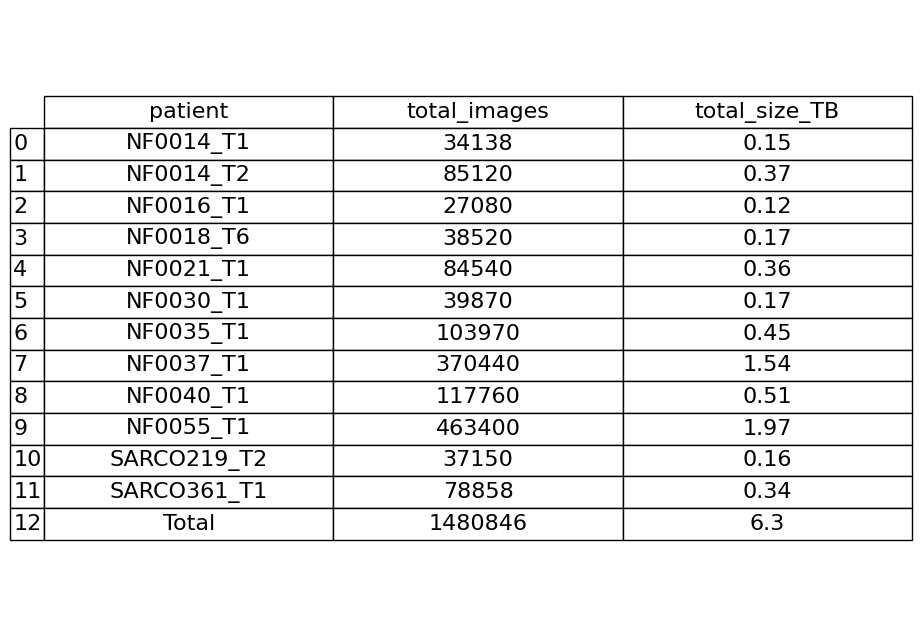

In [8]:
# save the table as a png
png_figure_path = pathlib.Path(f"{root_dir}/figures/table2/figures/file_info_table.png")
png_figure_path.parent.mkdir(parents=True, exist_ok=True)
if in_notebook:
    import matplotlib.pyplot as plt
    from pandas.plotting import table

    fig, ax = plt.subplots(figsize=(8, 8))  # Set the size of the figure
    ax.axis("off")  # Hide the axes
    tbl = table(ax, file_paths_df_grouped, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)  # Disable automatic font size
    tbl.set_fontsize(16)  # Set a fixed font size
    tbl.scale(1.4, 1.9)  # Scale the table to fit better
    plt.savefig(png_figure_path, bbox_inches="tight", dpi=300)